Dados de treino carregados: (98872, 18)
Dados de teste carregados: (5000, 17)
Estatísticas descritivas:
              idade  tempo_como_cliente  suporte_contatado  chamados_abertos  \
count  98872.000000        98872.000000       98872.000000      98872.000000   
mean      39.512228           60.366868           2.001315          0.993911   
std       10.011932           34.714797           1.413176          0.995506   
min       -4.000000            1.000000           0.000000          0.000000   
25%       33.000000           30.000000           1.000000          0.000000   
50%       40.000000           60.000000           2.000000          1.000000   
75%       46.000000           91.000000           3.000000          2.000000   
max       84.000000          120.000000          10.000000          8.000000   

       tempo_medio_atendimento   reclamacoes  atrasos_pagamento  \
count             98872.000000  98872.000000       98872.000000   
mean                 17.554497      0.500

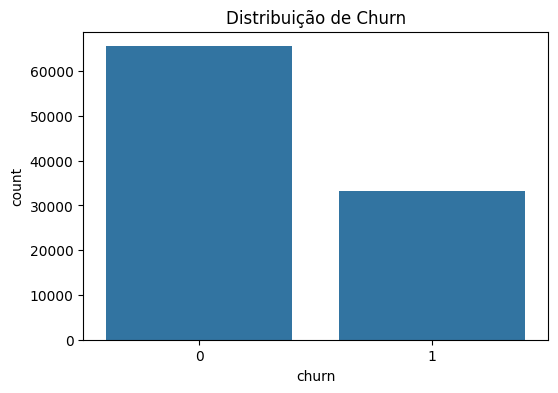

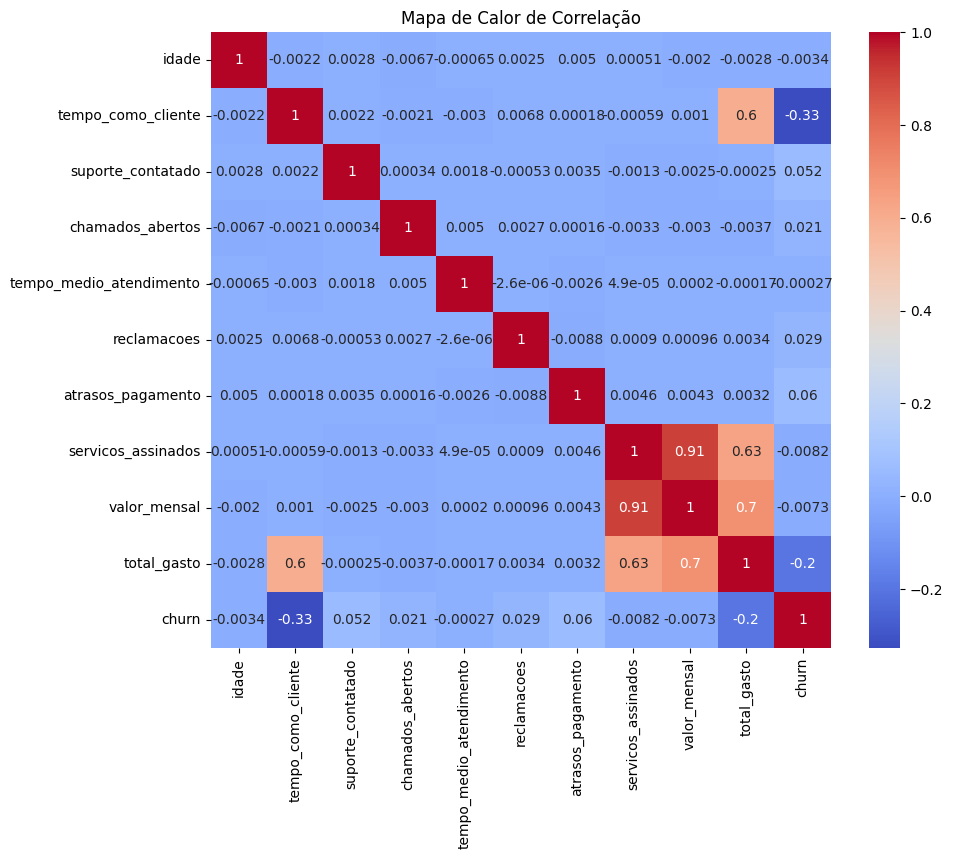

Formato X_train inicial: (98872, 16)
Formato X_test inicial: (5000, 16)
Valores ausentes no treino: idade                      0
genero                     0
estado_civil               0
tempo_como_cliente         0
tipo_contrato              0
forma_pagamento            0
suporte_contatado          0
chamados_abertos           0
tempo_medio_atendimento    0
reclamacoes                0
atrasos_pagamento          0
renda_faixa                0
servicos_assinados         0
produtos_assinados         0
valor_mensal               0
total_gasto                0
churn                      0
dtype: int64
Valores ausentes no teste: idade                      0
genero                     0
estado_civil               0
tempo_como_cliente         0
tipo_contrato              0
forma_pagamento            0
suporte_contatado          0
chamados_abertos           0
tempo_medio_atendimento    0
reclamacoes                0
atrasos_pagamento          0
renda_faixa                0
servicos_assinados 

NameError: name 'RandomForestClassifier' is not defined

In [10]:
# Previsão de Churn para Inteli Academy
# Este projeto preve o churn de clientes para a TelecomPlus usando aprendizado de máquina.

# -*- coding: utf-8 -*-
"""
Script para pré-processamento, treinamento e previsão de churn.
Este script realiza a análise completa do desafio de previsão de churn,
incluindo carregamento de dados, pré-processamento, exploração, treinamento de modelos,
avaliação, seleção do melhor modelo, previsão e análise de importância de features.
Modificado para incluir exploração de dados, tratamento de valores ausentes e visualizações.
"""

# --- 0. Importação das Bibliotecas Essenciais ---
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carregamento dos Dados ---
#Carregando os conjuntos de dados de treino (`dados_clientes.csv`) e teste (`desafio.csv`).
def load_data(train_path, test_path):
    """Carrega os datasets de treino e teste a partir dos caminhos especificados."""
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"Dados de treino carregados: {df_train.shape}")
    print(f"Dados de teste carregados: {df_test.shape}")
    return df_train, df_test

# --- 2. Exploração de Dados ---
# ALTERAÇÃO: Nova função para exploração de dados
def explore_data(df_train):
    """Explora o conjunto de dados de treino, exibindo estatísticas e visualizações."""
    print("Estatísticas descritivas:")
    print(df_train.describe())
    
    print("Distribuição de churn:")
    print(df_train['churn'].value_counts(normalize=True))
    plt.figure(figsize=(6, 4))
    sns.countplot(x='churn', data=df_train)
    plt.title('Distribuição de Churn')
    plt.savefig('./churn_distribution.png')
    plt.show()
    
    numerical_cols = df_train.select_dtypes(include=np.number).columns
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_train[numerical_cols].corr(), annot=True, cmap='coolwarm')
    plt.title('Mapa de Calor de Correlação')
    plt.savefig('./correlation_heatmap.png')
    plt.show()

# --- 3. Pré-processamento e Engenharia de Features ---
def preprocess_data(df_train, df_test):
    """Aplica pré-processamento e engenharia de features aos dados de treino e teste."""
    
    train_ids = df_train["id_cliente"]
    test_ids = df_test["id_cliente"]
    df_train = df_train.drop("id_cliente", axis=1)
    df_test = df_test.drop("id_cliente", axis=1)
    
    X_train = df_train.drop("churn", axis=1)
    y_train = df_train["churn"]
    X_test = df_test
    
    print(f"Formato X_train inicial: {X_train.shape}")
    print(f"Formato X_test inicial: {X_test.shape}")
    
    # ALTERAÇÃO: Tratamento de valores ausentes
    categorical_features = X_train.select_dtypes(include=["object"]).columns
    numerical_features = X_train.select_dtypes(include=np.number).columns
    print("Valores ausentes no treino:", df_train.isnull().sum())
    print("Valores ausentes no teste:", df_test.isnull().sum())
    for col in df_train.columns:
        if col in numerical_features:
            df_train[col] = df_train[col].fillna(df_train[col].median())
            df_test[col] = df_test[col].fillna(df_train[col].median())
        elif col in categorical_features:
            df_train[col] = df_train[col].fillna(df_train[col].mode()[0])
            df_test[col] = df_test[col].fillna(df_train[col].mode()[0])
    
    def parse_product_list(product_string):
        if isinstance(product_string, str):
            cleaned_string = re.sub(r"[\[\'\]]", "", product_string).strip()
            if not cleaned_string:
                return []
            products = re.split(r"\s+", cleaned_string)
            return [p for p in products if p]
        return []

    X_train["produtos_list"] = X_train["produtos_assinados"].apply(parse_product_list)
    X_test["produtos_list"] = X_test["produtos_assinados"].apply(parse_product_list)
    
    mlb = MultiLabelBinarizer()
    train_products_encoded = mlb.fit_transform(X_train["produtos_list"])
    test_products_encoded = mlb.transform(X_test["produtos_list"])
    
    product_columns = [f"produto_{cls}" for cls in mlb.classes_]
    df_train_products = pd.DataFrame(train_products_encoded, columns=product_columns, index=X_train.index)
    df_test_products = pd.DataFrame(test_products_encoded, columns=product_columns, index=X_test.index)
    
    X_train = pd.concat([X_train, df_train_products], axis=1)
    X_test = pd.concat([X_test, df_test_products], axis=1)
    X_train = X_train.drop(["produtos_assinados", "produtos_list"], axis=1)
    X_test = X_test.drop(["produtos_assinados", "produtos_list"], axis=1)
    
    print(f"Formato X_train após produtos: {X_train.shape}")
    print(f"Formato X_test após produtos: {X_test.shape}")
    
    categorical_features = X_train.select_dtypes(include=["object"]).columns
    numerical_features = X_train.select_dtypes(include=np.number).columns
    numerical_features = numerical_features.difference(product_columns)
    
    print(f"Features Categóricas: {list(categorical_features)}")
    print(f"Features Numéricas (para escalar): {list(numerical_features)}")

    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
    categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="passthrough"
    )
    
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    
    ohe_feature_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
    processed_feature_names = list(numerical_features) + list(ohe_feature_names) + list(product_columns)
    
    X_train_processed = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
    X_test_processed = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index)
    
    print(f"Formato X_train processado: {X_train_processed.shape}")
    print(f"Formato X_test processado: {X_test_processed.shape}")
    
    joblib.dump(preprocessor, "./data/preprocessor.joblib")
    joblib.dump(mlb, "./data/mlb.joblib")
    joblib.dump(processed_feature_names, "./data/feature_names.joblib")
    print("Pré-processador e nomes das features salvos.")
    
    return X_train_processed, X_test_processed, y_train, test_ids, processed_feature_names

# --- 4. Treinamento, Avaliação e Análise de Features ---
def train_evaluate_analyze(X_train, y_train, feature_names):
    """Treina múltiplos modelos, avalia usando validação cruzada e analisa importância das features."""
    models = {
        "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000, solver="liblinear"),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
    }
    
    results = {}
    trained_models = {}
    feature_importances = {}
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, model in models.items():
        print(f"\n--- Treinando e Avaliando: {name} ---")
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
        results[name] = cv_scores
        print(f"Acurácia (Validação Cruzada): {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
        
        # ALTERAÇÃO: Ajuste de hiperparâmetros para XGBoost se acurácia < 70%
        if name == "XGBoost" and np.mean(cv_scores) < 0.7:
            from sklearn.model_selection import GridSearchCV
            xgb_params = {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.01, 0.1]
            }
            grid = GridSearchCV(model, xgb_params, cv=cv, scoring='accuracy')
            grid.fit(X_train, y_train)
            model = grid.best_estimator_
            print(f"Melhores parâmetros para {name}:", grid.best_params_)
            cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
            results[name] = cv_scores
            print(f"Nova acurácia (Validação Cruzada): {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
        
        model.fit(X_train, y_train)
        trained_models[name] = model
        print(f"{name} treinado com todos os dados.")
        
        joblib.dump(model, f"./data/{name}_model.joblib")
        print(f"Modelo {name} salvo.")
        
        importance_df = analyze_feature_importance(model, feature_names, name)
        if importance_df is not None:
            feature_importances[name] = importance_df

        models['RandomForest'] = RandomForestClassifier(random_state=42, n_estimators=100)
    
    # ALTERAÇÃO: Adicionada validação com conjunto separado
    X_train_cv, X_val, y_train_cv, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    for name, model in trained_models.items():
        model.fit(X_train_cv, y_train_cv)
        val_accuracy = accuracy_score(y_val, model.predict(X_val))
        print(f"{name} Acurácia de Validação: {val_accuracy:.4f}")
        print(f"Relatório de Classificação para {name}:\n", classification_report(y_val, model.predict(X_val)))
    
    return trained_models, results, feature_importances

# --- 5. Seleção do Melhor Modelo e Previsão no Teste ---
def predict_on_test(trained_models, results, X_test, test_ids, output_filename):
    """Seleciona o melhor modelo com base na acurácia da validação cruzada e faz previsões no conjunto de teste."""
    best_model_name = max(results, key=lambda name: np.mean(results[name]))
    best_model = trained_models[best_model_name]
    print(f"\nMelhor modelo selecionado: {best_model_name} com acurácia média de {np.mean(results[best_model_name]):.4f}")

    
    
    predictions = best_model.predict(X_test)
    
    # ALTERAÇÃO: Renomeado CSV e colunas
    df_results = pd.DataFrame({
    "Id": test_ids,
    "churn": predictions
})
    df_results.to_csv(output_filename, index=False)
    print(f"Resultados salvos em: {output_filename}")
    
    # ALTERAÇÃO: Verificação do CSV
    print("Distribuição das previsões:", df_results['churn'].value_counts())
    
    return df_results, best_model_name, best_model

# --- 6. Análise de Feature Importance ---
def analyze_feature_importance(model, feature_names, model_name):
    """Analisa, imprime, plota e salva a importância das features."""
    if hasattr(model, "feature_importances_"):
        print(f"\n--- Análise de Feature Importance para {model_name} ---")
        importances = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)
        
        print("Top 10 Features mais importantes:")
        print(feature_importance_df.head(10).to_markdown(index=False))
        
        # ALTERAÇÃO: Adicionado gráfico
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
        plt.title(f'Top 10 Importância de Features - {model_name}')
        plt.savefig(f'./{model_name}_feature_importance.png')
        plt.show()
        
        output_path = f"./data/{model_name}_feature_importance.csv"
        feature_importance_df.to_csv(output_path, index=False)
        print(f"Importância das features salva em {output_path}")
        return feature_importance_df
    else:
        print(f"\nModelo {model_name} não suporta análise direta de feature importance.")
        return None

# --- Execução Principal do Script ---
if __name__ == "__main__":
    # ALTERAÇÃO: Atualizado caminho do CSV de saída
    TRAIN_DATA_PATH = "./data/dados_clientes.csv"
    TEST_DATA_PATH = "./data/desafio.csv"
    OUTPUT_CSV_PATH = "./data/resultado_yourname_yoursurname.csv"
    
    df_train, df_test = load_data(TRAIN_DATA_PATH, TEST_DATA_PATH)
    
    # ALTERAÇÃO: Chamada da exploração de dados
    explore_data(df_train)
    
    X_train_processed, X_test_processed, y_train, test_ids, feature_names = preprocess_data(df_train, df_test)
    
    trained_models, results, feature_importances = train_evaluate_analyze(X_train_processed, y_train, feature_names)
    
    df_results, best_model_name, best_model = predict_on_test(trained_models, results, X_test_processed, test_ids, OUTPUT_CSV_PATH)
    
    if "XGBoost" in feature_importances:
        print("\nAnálise de Feature Importance do XGBoost foi concluída e salva.")
    elif "XGBoost" in trained_models:
        print("\nModelo XGBoost treinado, mas a análise de importância não foi gerada.")
    else:
        print("\nModelo XGBoost não foi treinado.")
    
    print("\nProcesso concluído!")